# Comparación de kernels SVM (lineal, polinómico y RBF)

Este notebook entrena y compara **tres modelos SVM** con kernels:
- `linear`
- `poly` (polinómico)
- `rbf`

Incluye:
- carga/generación del dataset (con *fallback* a `make_moons` si no existe CSV)
- exploración y visualización
- partición train/test + escalado
- entrenamiento y evaluación (accuracy, classification report, matriz de confusión)
- visualización de fronteras de decisión


In [1]:
# 1) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.datasets import make_moons

%matplotlib inline


## 2) Carga del dataset

El notebook intenta cargar un CSV llamado **`moons_dataset.csv`** con columnas:
- `x1`, `x2` (variables)
- `clase` (0/1)

Si **no existe**, lo genera con `make_moons` y lo guarda como CSV para reutilizarlo.


In [4]:
# 2) Carga o generación del dataset
CSV_PATH = "make_moons.csv"

try:
    df = pd.read_csv(CSV_PATH)
    # Validación mínima de columnas
    expected_cols = {"x1", "x2", "clase"}
    if not expected_cols.issubset(df.columns):
        raise ValueError(f"El CSV debe tener columnas {expected_cols}. Encontradas: {set(df.columns)}")
    print(f"✅ Dataset cargado desde: {CSV_PATH}  |  shape={df.shape}")
except Exception as e:
    print(f"⚠️ No se pudo cargar '{CSV_PATH}' ({e}). Generando dataset con make_moons...")
    X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
    df = pd.DataFrame(X, columns=["x1", "x2"])
    df["clase"] = y
    df.to_csv(CSV_PATH, index=False)
    print(f"✅ Dataset generado y guardado en: {CSV_PATH}  |  shape={df.shape}")

df.head()


⚠️ No se pudo cargar 'make_moons.csv' ([Errno 2] No such file or directory: 'make_moons.csv'). Generando dataset con make_moons...
✅ Dataset generado y guardado en: make_moons.csv  |  shape=(400, 3)


,x1,x2,clase
0,-0.125245,0.552601,1
1,0.685084,-0.323315,1
2,0.769488,0.607225,0
3,0.428378,0.157977,1
4,0.075636,0.873185,0


## 3) Exploración rápida y visualización

Primero miramos:
- tipos de datos
- balance de clases
- dispersión (scatter) coloreada por clase


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      400 non-null    float64
 1   x2      400 non-null    float64
 2   clase   400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


None

clase
1    200
0    200
Name: count, dtype: int64

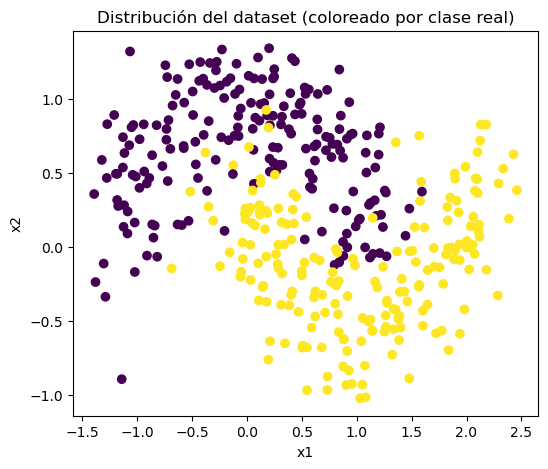

In [5]:
# 3) Exploración rápida
display(df.info())
display(df["clase"].value_counts())

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(df["x1"], df["x2"], c=df["clase"])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Distribución del dataset (coloreado por clase real)")
plt.show()


## 4) Preparación: X/y, train-test split y escalado

En SVM el escalado suele ser importante.  
Se escala **solo con el train** (fit) y luego se aplica al test (transform).


In [6]:
# 4) X / y
X = df[["x1", "x2"]]
y = df["clase"]

# Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " | Test:", X_test.shape)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: (320, 2)  | Test: (80, 2)


## 5) Definición de modelos SVM (3 kernels)

Para una comparación justa:
- mismo `C` en los tres
- `degree` definido en polinómico
- `gamma="scale"` en RBF (valor razonable por defecto)


In [7]:
# 5) Modelos
modelos = {
    "SVM lineal": SVC(kernel="linear", C=1, random_state=42),
    "SVM polinómico (grado 3)": SVC(kernel="poly", degree=3, C=1, gamma="scale", random_state=42),
    "SVM RBF": SVC(kernel="rbf", C=1, gamma="scale", random_state=42),
}


## 6) Entrenamiento, predicción y evaluación

Para cada modelo:
- entrenamos (`fit`)
- predecimos (`predict`) → **`y_pred`**
- medimos accuracy
- mostramos `classification_report`
- dibujamos matriz de confusión


SVM lineal
Accuracy: 0.938

Classification report:
              precision    recall  f1-score   support

           0      0.949     0.925     0.937        40
           1      0.927     0.950     0.938        40

    accuracy                          0.938        80
   macro avg      0.938     0.938     0.937        80
weighted avg      0.938     0.938     0.937        80



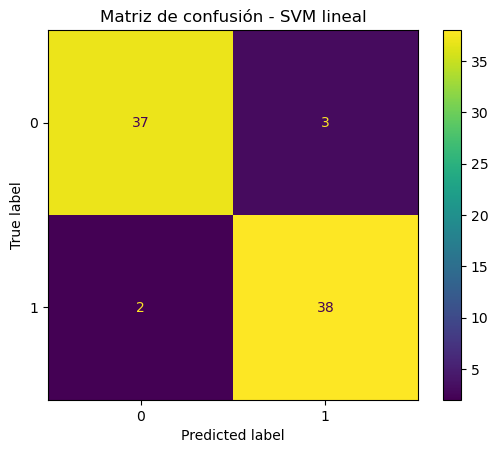

SVM polinómico (grado 3)
Accuracy: 0.912

Classification report:
              precision    recall  f1-score   support

           0      0.867     0.975     0.918        40
           1      0.971     0.850     0.907        40

    accuracy                          0.912        80
   macro avg      0.919     0.912     0.912        80
weighted avg      0.919     0.912     0.912        80



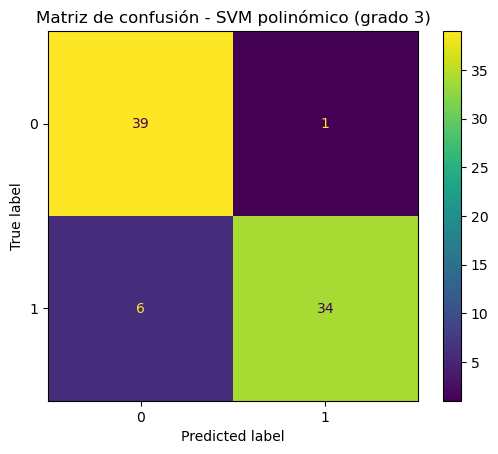

SVM RBF
Accuracy: 0.925

Classification report:
              precision    recall  f1-score   support

           0      0.972     0.875     0.921        40
           1      0.886     0.975     0.929        40

    accuracy                          0.925        80
   macro avg      0.929     0.925     0.925        80
weighted avg      0.929     0.925     0.925        80



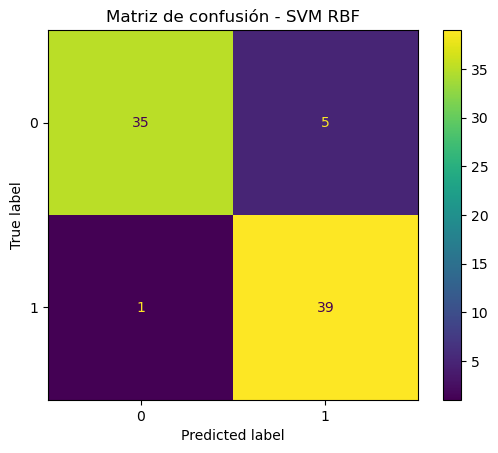

,Accuracy
SVM lineal,0.9375
SVM RBF,0.9250
SVM polinómico (grado 3),0.9125


In [8]:
# 6) Entrenamiento + evaluación
resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc

    print("="*70)
    print(nombre)
    print(f"Accuracy: {acc:.3f}\n")
    print("Classification report:")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

resultados_df = pd.DataFrame.from_dict(resultados, orient="index", columns=["Accuracy"]).sort_values("Accuracy", ascending=False)
resultados_df


## 7) Visualización de fronteras de decisión

Esta parte ayuda a **entender** la diferencia entre kernels.

La idea:
1. Creamos una “rejilla” de puntos en el plano (x1, x2)
2. Predecimos la clase de cada punto con el modelo
3. Dibujamos la región predicha y encima los puntos reales



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


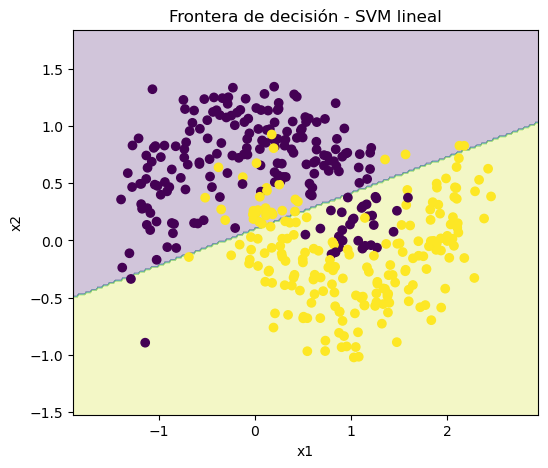

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


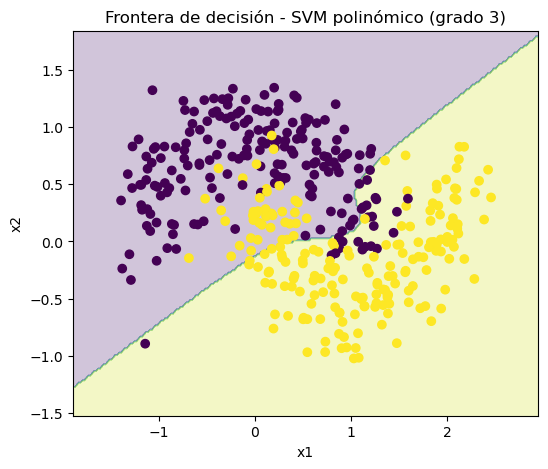

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


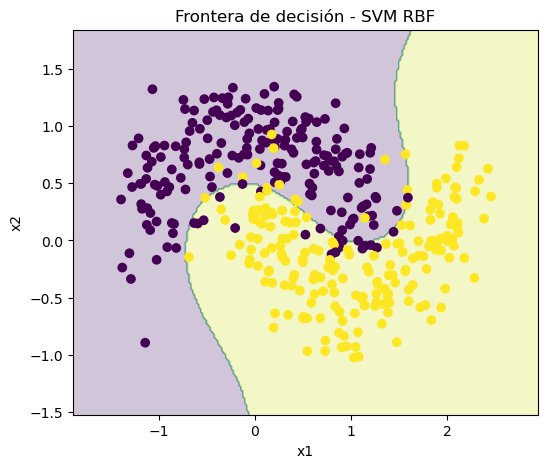

In [9]:
def plot_decision_boundary(model, scaler, X_raw, y, title=""):
    """Dibuja la frontera de decisión en 2D para un modelo entrenado sobre variables escaladas."""
    # Rango del gráfico
    x_min, x_max = X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5
    y_min, y_max = X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5

    # Rejilla
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid_raw = np.c_[xx.ravel(), yy.ravel()]

    # Escalado coherente con el entrenamiento
    grid_scaled = scaler.transform(grid_raw)

    # Predicción sobre la rejilla
    Z = model.predict(grid_scaled).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

# Datos en formato numpy para dibujar
X_raw = X.values
y_raw = y.values

for nombre, modelo in modelos.items():
    plot_decision_boundary(modelo, scaler, X_raw, y_raw, title=f"Frontera de decisión - {nombre}")
